In [1]:
import pandas as pd
import numpy as np

from dp_evaluation import MembershipInferenceAttack, EuclideanDistanceAttack
from differential_privacy import DifferentialPrivacy
from explanation_collection import explanation_collection


from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import pickle


from ucimlrepo import fetch_ucirepo

# Fetch dataset
dataset_id = 891
uci_dataset = fetch_ucirepo(id=dataset_id)

# Data (as pandas dataframes)
X = uci_dataset.data.features
y = uci_dataset.data.targets

data = pd.concat([X, y], axis=1)

target_col = y.columns[0]

numerical_columns = ['BMI', 'GenHlth', 'MentHlth', 'PhysHlth', 'Age', 'Education', 'Income']

# Select the remaining columns as categorical columns
all_columns = set(X.columns)
categorical_columns = list(all_columns - set(numerical_columns))

In [2]:
from preprocessing_pipeline import PreprocessingPipeline
pipeline = PreprocessingPipeline()

steps_prior = [
    'drop_missing_values',

    'encode_categorical_variables',
]

X, y = pipeline.preprocess(data, target_col, numerical_columns, categorical_columns, steps_prior)

if dataset_id == 2:
    y = np.where((y == 0) | (y == 1), 0, 1)

Missing Values Dropped: 0 rows removed
Percentage of rows dropped due to missing values: 0.00%
number of categorical columns '14


In [3]:
# Split the dataset into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42)

# Convert y_train to a pandas Series and reset index
y_train = pd.Series(y_train, name=target_col).reset_index(drop=True)
y_test = pd.Series(y_test, name=target_col).reset_index(drop=True)

# Reset index of X_train
X_train = X_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)

# Convert X_train and X_test to pandas DataFrame
X_train_df = pd.DataFrame(X_train, columns=X.columns)
X_test_df = pd.DataFrame(X_test, columns=X.columns)

# Initialize and train the target model
target_model = RandomForestClassifier()
target_model.fit(X_train, y_train)

# Initialize MembershipInferenceAttack class
mia = MembershipInferenceAttack(target_model)

X_shared = X_train
y_shared = y_train

# Create shadow datasets
shadow_datasets = mia.create_shadow_datasets(X_shared, y_shared)

# Train shadow models
shadow_models = mia.train_shadow_models(shadow_datasets)

# Initialize the explanation collection
lime_explainer = explanation_collection()

# Generate attack data with LIME explanations
attack_data, attack_labels = mia.generate_attack_data(shadow_models, shadow_datasets, lime_explainer=lime_explainer, sample_size=5000)

# Train attack model
attack_model = mia.train_attack_model(attack_data, attack_labels)

# Evaluate attack model on target model
# Using both training and test sets to see the effectiveness of the attack
target_train_labels = np.ones(len(X_train))
target_test_labels = np.zeros(len(X_test))

# Evaluate attack model on target model
train_accuracy = mia.evaluate_attack(attack_model, X_train, target_train_labels, lime_explainer=lime_explainer, sample_size=1000)
test_accuracy = mia.evaluate_attack(attack_model, X_test, target_test_labels, lime_explainer=lime_explainer, sample_size=1000)

# print(f"Shape of X_train: {X_train.shape}")
print(f"Membership Inference Attack Accuracy on Training Data: {train_accuracy}")
print(f"Membership Inference Attack Accuracy on Test Data: {test_accuracy}")

100%|███████████████████████████████████████| 1000/1000 [05:48<00:00,  2.87it/s]

Membership Inference Attack Accuracy on Training Data: 0.00575528224534847
Membership Inference Attack Accuracy on Test Data: 0.9969094922737307


In [4]:
X_shared.shape

(126840, 21)

In [5]:
# # Combine the attack model's evaluation on both training and test data
# combined_X = np.vstack([X_train, X_test])  # Stack training and test data
# combined_labels = np.concatenate([target_train_labels, target_test_labels])  # Combine the labels (1 for train, 0 for test)

# # Evaluate the attack model on the combined dataset
# combined_accuracy = mia.evaluate_attack(attack_model, combined_X, combined_labels)

# print(f"Combined Membership Inference Attack Accuracy: {combined_accuracy}")

100%|███████████████████████████████████████| 1000/1000 [05:54<00:00,  2.82it/s]


Epsilon: 1, Membership Inference Attack Accuracy on Noisy Data: 0.00521917376222012


100%|███████████████████████████████████████| 1000/1000 [05:49<00:00,  2.86it/s]


Epsilon: 5, Membership Inference Attack Accuracy on Noisy Data: 0.00532166508987701


100%|███████████████████████████████████████| 1000/1000 [02:30<00:00,  6.66it/s]


Epsilon: 10, Membership Inference Attack Accuracy on Noisy Data: 0.006228319142226427


100%|███████████████████████████████████████| 1000/1000 [02:32<00:00,  6.56it/s]


Epsilon: 50, Membership Inference Attack Accuracy on Noisy Data: 0.006015452538631346


100%|███████████████████████████████████████| 1000/1000 [02:32<00:00,  6.55it/s]


Epsilon: 100, Membership Inference Attack Accuracy on Noisy Data: 0.29418164616840115


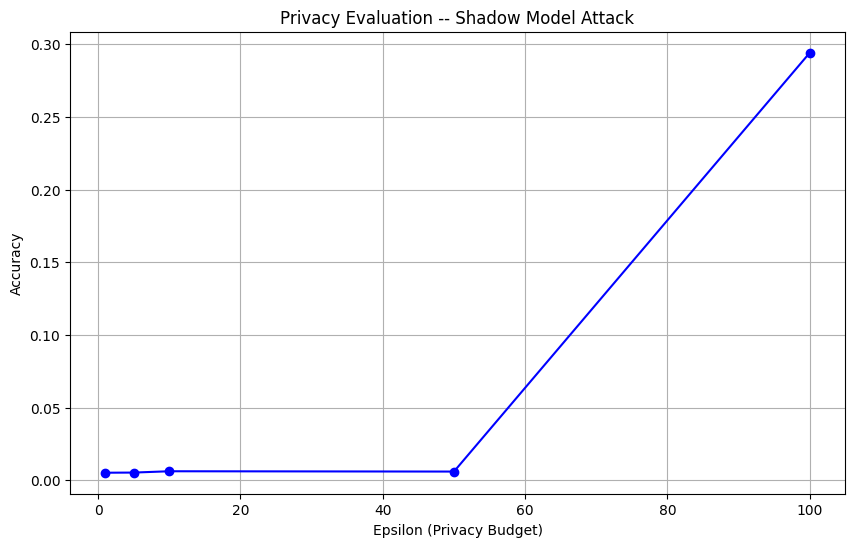

In [6]:
# Experiment with different levels of noise
epsilons = [1, 5, 10, 50, 100]
attack_accuracies = []

for epsilon in epsilons:
    dp = DifferentialPrivacy(epsilon)
    
    # Add noise to the features with rounding to nearest integers and clamping
    noisy_X_shared_df = dp.apply_differential_privacy(X_shared, numerical_columns, categorical_columns, round_to_int=True)
    
    # Convert noisy_X_train_df back to numpy array
    noisy_X_shared = noisy_X_shared_df.copy()
    
    # Create shadow datasets from noisy data
    noisy_shadow_datasets = mia.create_shadow_datasets(noisy_X_shared, y_shared)
    
    # Train shadow models on noisy data
    noisy_shadow_models = mia.train_shadow_models(noisy_shadow_datasets)
    
    # Generate attack data from noisy shadow models
    noisy_attack_data, noisy_attack_labels = mia.generate_attack_data(noisy_shadow_models, noisy_shadow_datasets, lime_explainer=lime_explainer, sample_size=5000)
    
    # Train attack model on noisy attack data
    noisy_attack_model = mia.train_attack_model(noisy_attack_data, noisy_attack_labels)
        
    # Evaluate the attack on noisy data
    noisy_train_accuracy = mia.evaluate_attack(noisy_attack_model, X_train, target_train_labels, lime_explainer=lime_explainer, sample_size=1000)
    attack_accuracies.append(noisy_train_accuracy)
    print(f"Epsilon: {epsilon}, Membership Inference Attack Accuracy on Noisy Data: {noisy_train_accuracy}")

# Save the attack accuracies to a pickle file
with open(f'SMA_accuracies_{dataset_id}.pkl', 'wb') as f:
    pickle.dump(attack_accuracies, f)
    
# Plot the attack accuracy vs. epsilon
plt.figure(figsize=(10, 6))
plt.plot(epsilons, attack_accuracies, marker='o', linestyle='solid', color='b')
plt.xlabel('Epsilon (Privacy Budget)')
plt.ylabel('Accuracy')
plt.title('Privacy Evaluation -- Shadow Model Attack')
plt.grid(True)
plt.show()

Average ratio of case group distances below threshold: 0.155
Average ratio of case group distances below threshold: 0.16
Average ratio of case group distances below threshold: 0.315
Average ratio of case group distances below threshold: 0.44
Average ratio of case group distances below threshold: 1.0


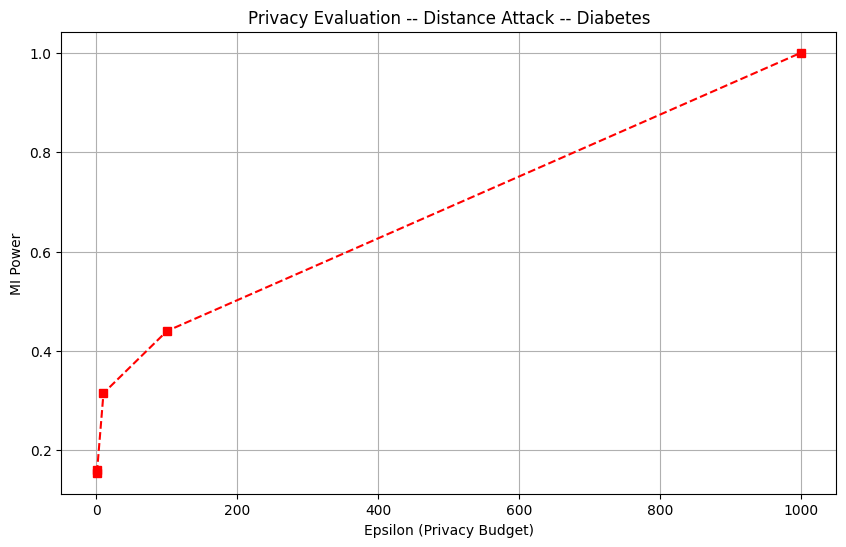

In [3]:
epsilons = [0.1, 1, 10, 100, 1000]

eda_power = []
for epsilon in epsilons:
    eda = EuclideanDistanceAttack(epsilon, n=200, num_repeats=10, numerical_columns=numerical_columns, categorical_columns=categorical_columns)

    # Perform the Euclidean distance attack and calculate the average ratio
    average_ratio_below_threshold = eda.repeat_attack(X, y)
    print(f"Average ratio of case group distances below threshold: {average_ratio_below_threshold}")
    eda_power.append(average_ratio_below_threshold)

# Save the attack accuracies to a pickle file
with open(f'MIA_accuracies_{dataset_id}.pkl', 'wb') as f:
    pickle.dump(eda_power, f)
        
plt.figure(figsize=(10, 6))
plt.plot(epsilons, eda_power, marker='s', linestyle='dashed', color='r')
plt.xlabel('Epsilon (Privacy Budget)')
plt.ylabel('MI Power')
plt.title('Privacy Evaluation -- Distance Attack -- Diabetes')
plt.grid(True)
plt.show()

<!-- 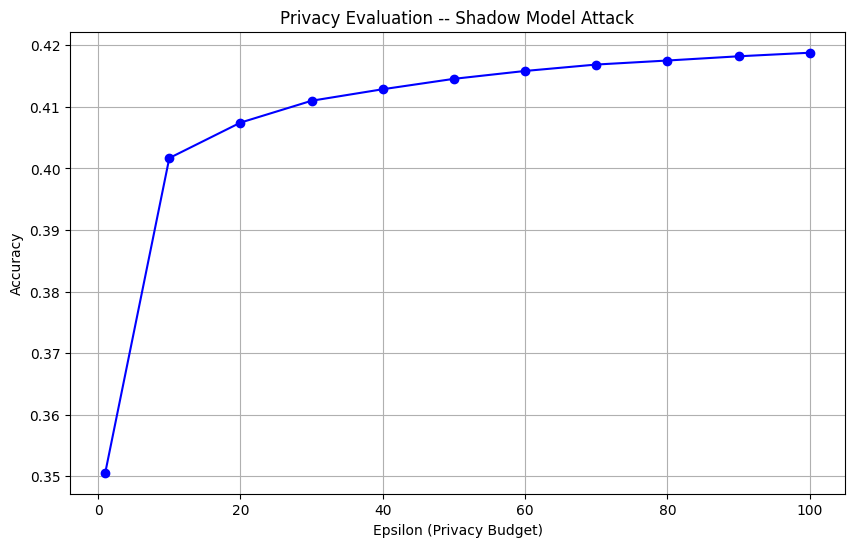 -->

<!-- 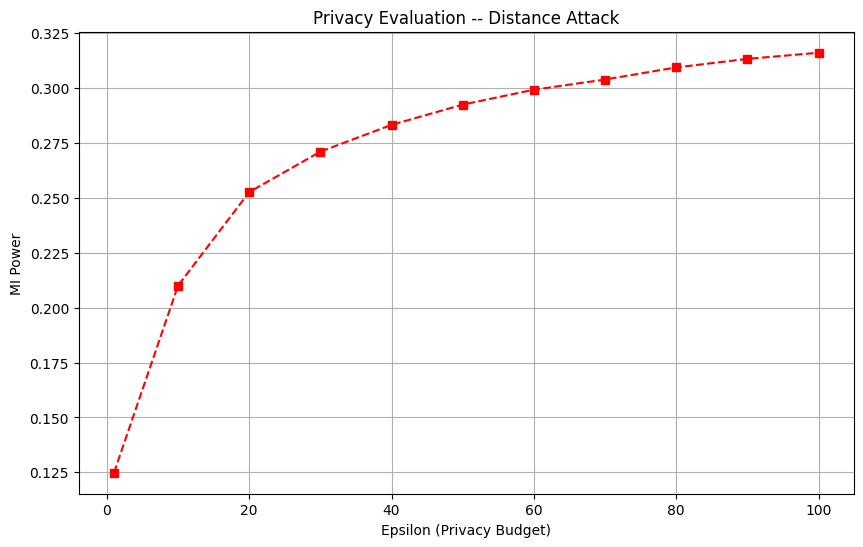 -->